# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Load in the "states_edu.csv" dataset and take a look at the head of the data

In [3]:
df = pd.read_csv("../data/states_edu.csv")

You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [4]:
df.columns

df.rename({
    'GRADES_PK_G':'ENROLL_PREK',
    'GRADES_KG_G':'ENROLL_KINDER',
    'GRADES_4_G':'ENROLL_4',
    'GRADES_8_G':'ENROLL_8',
    'GRADES_12_G':'ENROLL_12',
    'GRADES_1_8_G':'ENROLL_PRIMARY',
    'GRADES_9_12_G':'ENROLL_HS',
    'GRADES_ALL_G':'ENROLL_ALL',
    'ENROLL':'ENROLL_ALL_EST'
    },
    axis=1, inplace=True)

df.columns

Index(['PRIMARY_KEY', 'STATE', 'YEAR', 'ENROLL_ALL_EST', 'TOTAL_REVENUE',
       'FEDERAL_REVENUE', 'STATE_REVENUE', 'LOCAL_REVENUE',
       'TOTAL_EXPENDITURE', 'INSTRUCTION_EXPENDITURE',
       'SUPPORT_SERVICES_EXPENDITURE', 'OTHER_EXPENDITURE',
       'CAPITAL_OUTLAY_EXPENDITURE', 'ENROLL_PREK', 'ENROLL_KINDER',
       'ENROLL_4', 'ENROLL_8', 'ENROLL_12', 'ENROLL_PRIMARY', 'ENROLL_HS',
       'ENROLL_ALL', 'AVG_MATH_4_SCORE', 'AVG_MATH_8_SCORE',
       'AVG_READING_4_SCORE', 'AVG_READING_8_SCORE'],
      dtype='str')

In [5]:
df.isna().sum()

df.notna().sum()

PRIMARY_KEY                     1715
STATE                           1715
YEAR                            1715
ENROLL_ALL_EST                  1224
TOTAL_REVENUE                   1275
FEDERAL_REVENUE                 1275
STATE_REVENUE                   1275
LOCAL_REVENUE                   1275
TOTAL_EXPENDITURE               1275
INSTRUCTION_EXPENDITURE         1275
SUPPORT_SERVICES_EXPENDITURE    1275
OTHER_EXPENDITURE               1224
CAPITAL_OUTLAY_EXPENDITURE      1275
ENROLL_PREK                     1542
ENROLL_KINDER                   1632
ENROLL_4                        1632
ENROLL_8                        1632
ENROLL_12                       1632
ENROLL_PRIMARY                  1020
ENROLL_HS                       1071
ENROLL_ALL                      1632
AVG_MATH_4_SCORE                 565
AVG_MATH_8_SCORE                 602
AVG_READING_4_SCORE              650
AVG_READING_8_SCORE              562
dtype: int64

In [6]:
df.dropna(subset=['AVG_MATH_8_SCORE'], inplace=True)

In [7]:
df["ENROLL_ALL"].isna().sum()

np.int64(74)

In [8]:
(df["ENROLL_ALL"]-df["ENROLL_PREK"]-df["ENROLL_KINDER"]-df["ENROLL_PRIMARY"]-df["ENROLL_HS"]).describe()

count       394.000000
mean       4945.781726
std       17269.335326
min           0.000000
25%           0.000000
50%           0.000000
75%        1012.000000
max      147954.000000
dtype: float64

In [9]:
((df["ENROLL_ALL"]-df["ENROLL_PREK"]-df["ENROLL_KINDER"]-df["ENROLL_PRIMARY"]-df["ENROLL_HS"])/df["ENROLL_ALL"]*100).describe()


count    394.000000
mean       0.420306
std        1.090873
min        0.000000
25%        0.000000
50%        0.000000
75%        0.188212
max        7.702014
dtype: float64

In [12]:
df['ENROLL_ALL'] = df['ENROLL_ALL'].fillna(df["ENROLL_PREK"]+df["ENROLL_KINDER"]+df["ENROLL_PRIMARY"]+df["ENROLL_HS"])

df["ENROLL_ALL"].isna().sum()

df[df["ENROLL_ALL"].isna()][['ENROLL_PREK','ENROLL_PRIMARY','ENROLL_HS','ENROLL_ALL_EST']].notna().any()

ENROLL_PREK       False
ENROLL_PRIMARY    False
ENROLL_HS         False
ENROLL_ALL_EST    False
dtype: bool

In [13]:
df[df.ENROLL_ALL_EST.isna()]["ENROLL_ALL"].notna().sum()

np.int64(131)

In [15]:
df

,PRIMARY_KEY,STATE,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,ENROLL_4,ENROLL_8,ENROLL_12,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN
5,1992_COLORADO,COLORADO,1992,NaN,3185173.0,163253.0,1307986.0,1713934.0,3264826.0,1642466.0,...,50648.0,45025.0,34533.0,NaN,NaN,612635.0,221.0,272.0,217.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710,2019_VIRGINIA,VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,247.0,287.0,224.0,262.0
1711,2019_WASHINGTON,WASHINGTON,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,240.0,286.0,220.0,266.0
1712,2019_WEST_VIRGINIA,WEST_VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,231.0,272.0,213.0,256.0
1713,2019_WISCONSIN,WISCONSIN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,242.0,289.0,220.0,267.0


<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: *ENTER YOUR CHOICE HERE*

How many years of data are logged in our dataset? 

In [19]:
# @@@ 1
# Your Code
number_of_years = df['YEAR'].nunique()
Year_range = list(df['YEAR'].unique())

number_of_years



13

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [23]:
# @@@ 2
from ast import If


Michigan_df = df[df['STATE']=='MICHIGAN']
Michigan_df['AVG_MATH_8_SCORE'].mean()

Ohio_df = df[df['STATE']=='OHIO']
Ohio_df['AVG_MATH_8_SCORE'].mean()

if Michigan_df['AVG_MATH_8_SCORE'].mean() > Ohio_df['AVG_MATH_8_SCORE'].mean():
    print("Michigan has a higher average score than Ohio")
else:
    print("Ohio has a higher average score than Michigan")

Ohio has a higher average score than Michigan


Find the average for your chosen test across all states in 2019

In [29]:
# @@@ 3
All_states_df = df[df['YEAR'] == 2019].groupby('STATE')['AVG_MATH_8_SCORE'].mean().reset_index()
print(All_states_df)


                   STATE  AVG_MATH_8_SCORE
0                ALABAMA             269.0
1                 ALASKA             274.0
2                ARIZONA             280.0
3               ARKANSAS             274.0
4             CALIFORNIA             276.0
5               COLORADO             285.0
6            CONNECTICUT             286.0
7               DELAWARE             277.0
8   DISTRICT_OF_COLUMBIA             269.0
9                  DODEA             292.0
10               FLORIDA             279.0
11               GEORGIA             279.0
12                HAWAII             275.0
13                 IDAHO             286.0
14              ILLINOIS             283.0
15               INDIANA             286.0
16                  IOWA             282.0
17                KANSAS             282.0
18              KENTUCKY             278.0
19             LOUISIANA             272.0
20                 MAINE             282.0
21              MARYLAND             280.0
22         

For each state, find a maximum value for your chosen test score

In [32]:
# @@@ 4
All_states_df2 = df.groupby('STATE')['AVG_MATH_8_SCORE'].max().reset_index()
print(All_states_df2)

                   STATE  AVG_MATH_8_SCORE
0                ALABAMA             269.0
1                 ALASKA             283.0
2                ARIZONA             283.0
3               ARKANSAS             279.0
4             CALIFORNIA             277.0
5               COLORADO             292.0
6            CONNECTICUT             289.0
7               DELAWARE             284.0
8   DISTRICT_OF_COLUMBIA             269.0
9                  DODEA             293.0
10               FLORIDA             281.0
11               GEORGIA             281.0
12                HAWAII             281.0
13                 IDAHO             287.0
14              ILLINOIS             285.0
15               INDIANA             288.0
16                  IOWA             286.0
17                KANSAS             290.0
18              KENTUCKY             282.0
19             LOUISIANA             273.0
20                 MAINE             289.0
21              MARYLAND             288.0
22         

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [42]:
# @@@ 5
df['Money_score_index'] = (
    df['AVG_MATH_8_SCORE'] / df['TOTAL_EXPENDITURE'] * 1_000_000
)

df

#I want to explore the relationship between the total money spent on education and the avarage math score of 8th graders. The higher the money score index, the more efficient the state is in spending money on education.

,PRIMARY_KEY,STATE,YEAR,ENROLL_ALL_EST,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,ENROLL_12,ENROLL_PRIMARY,ENROLL_HS,ENROLL_ALL,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE,Instruction_index,Money_score_index
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN,94.958245,94.958245
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN,77.904974,77.904974
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN,146.871353,146.871353
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN,9.617216,9.617216
5,1992_COLORADO,COLORADO,1992,NaN,3185173.0,163253.0,1307986.0,1713934.0,3264826.0,1642466.0,...,34533.0,NaN,NaN,612635.0,221.0,272.0,217.0,NaN,83.312250,83.312250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1710,2019_VIRGINIA,VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,247.0,287.0,224.0,262.0,NaN,NaN
1711,2019_WASHINGTON,WASHINGTON,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,240.0,286.0,220.0,266.0,NaN,NaN
1712,2019_WEST_VIRGINIA,WEST_VIRGINIA,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,231.0,272.0,213.0,256.0,NaN,NaN
1713,2019_WISCONSIN,WISCONSIN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,242.0,289.0,220.0,267.0,NaN,NaN


Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

<Axes: title={'center': 'Average Money Score Index by State'}, xlabel='State', ylabel='Average Money Score Index'>

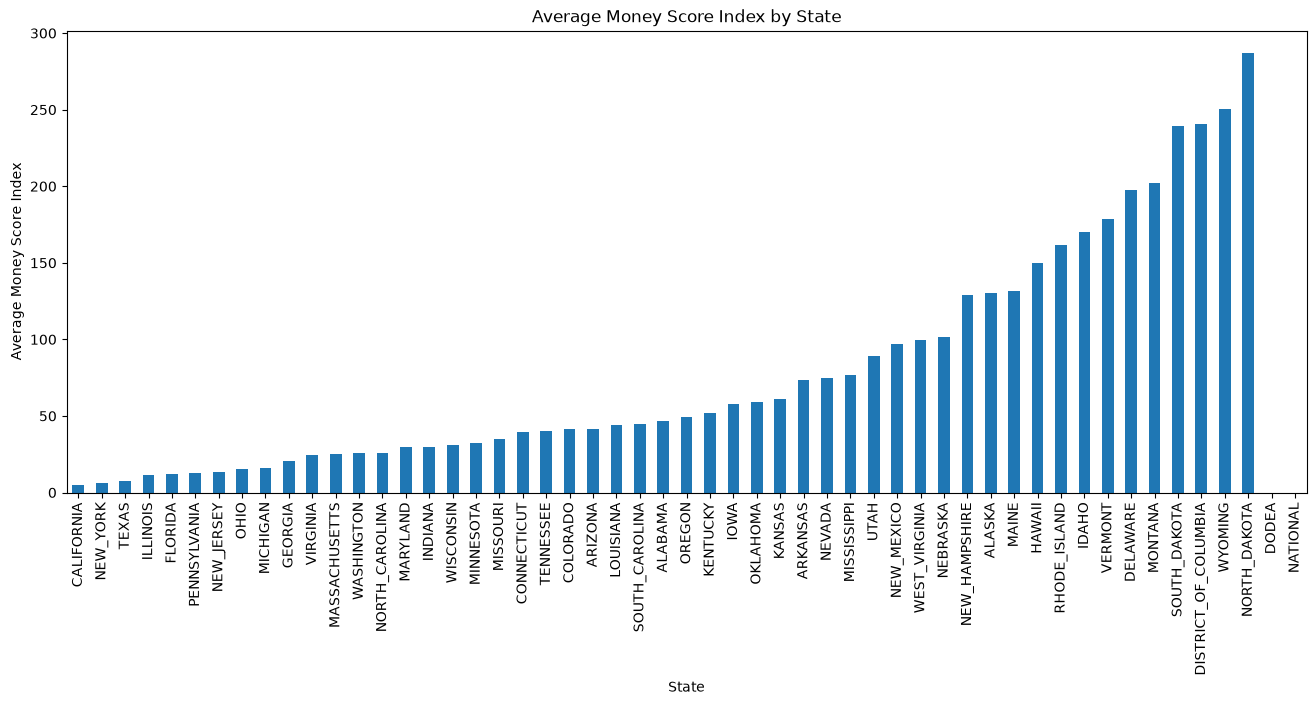

In [46]:
# @@@ 6
state_money_index = (
    df.groupby('STATE')['Money_score_index']
      .mean()
      .sort_values()
)

state_money_index.plot.bar(
    title='Average Money Score Index by State',
    xlabel='State',
    ylabel='Average Money Score Index',
    figsize=(16, 6)
)

**<CAPTION FOR VIZ 1>**

**Visualization 2**

<Axes: title={'center': 'Average Reading vs Math Score for 8th Graders'}, xlabel='AVG_READING_8_SCORE', ylabel='AVG_MATH_8_SCORE'>

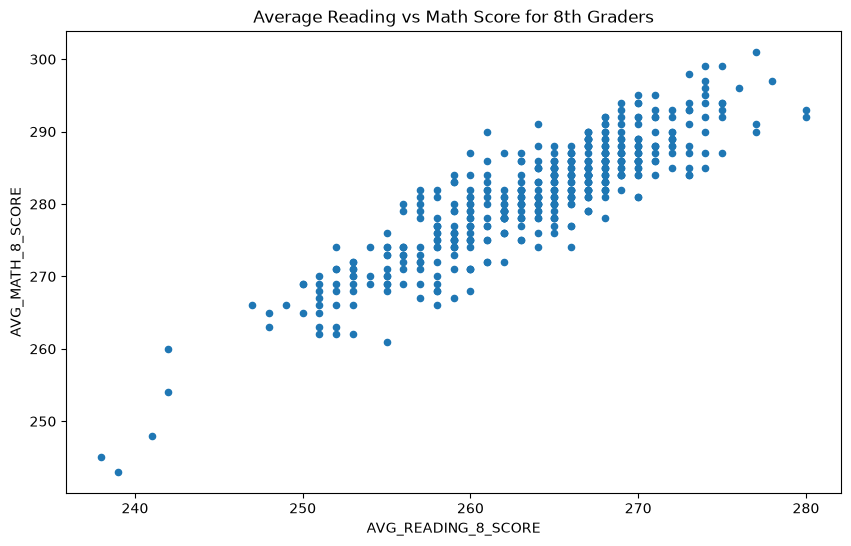

In [47]:
# @@@ 7
df.plot.scatter(x='AVG_READING_8_SCORE', y='AVG_MATH_8_SCORE', title = 'Average Reading vs Math Score for 8th Graders', figsize=(10, 6))

**<CAPTION FOR VIZ 2>**

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [48]:
from sklearn.model_selection import train_test_split

In [ ]:
# @@@ 8

X = df[['ENROLL_8', 'AVG_READING_8_SCORE', 'TOTAL_EXPENDITURE']].dropna()
y = df.loc[X.index]['AVG_MATH_8_SCORE']

In [51]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [52]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [53]:
# @@@ 11
# create your model here
# model = 
model = LinearRegression()

In [54]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0., 0., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['ENROLL_8','AVG_READING_8_SCORE','TOTAL_EXPENDITURE']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,280.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [55]:
y_pred = model.predict(X_test)

In [57]:
print(model.intercept_)
print(model.coef_)

280.78920397512803
[-9.65048809e-05  8.63869204e-09  6.47406412e-07]


## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [58]:
# @@@ 12
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("R² score:", r2_score(y_test, y_pred))
print("Mean absolute error:", mean_absolute_error(y_test, y_pred))
print("Root mean squared error:", mean_squared_error(y_test, y_pred) ** 0.5)

R² score: -0.1728679931280781
Mean absolute error: 6.289909066344655
Root mean squared error: 7.925374485546346


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior on Training Set')

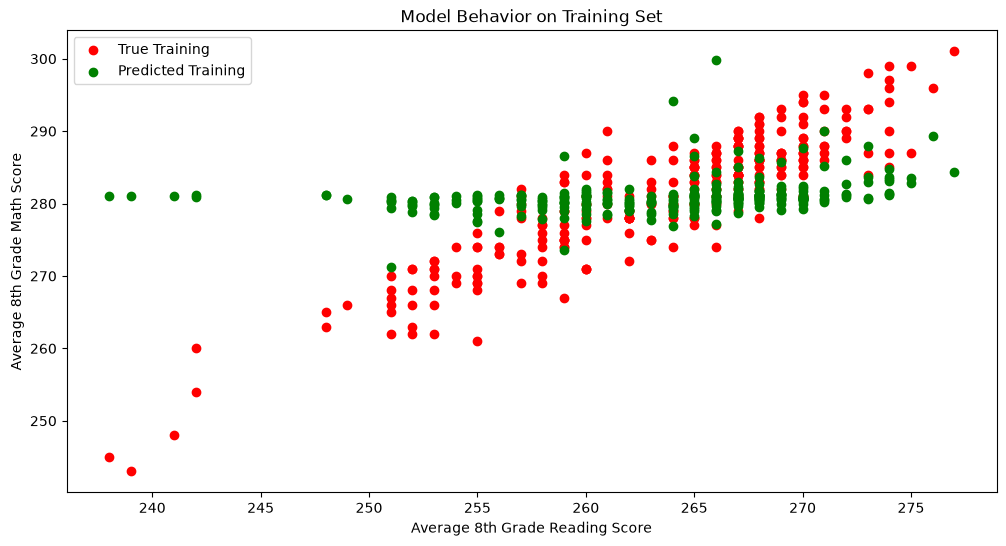

In [59]:
# @@@ 13

col_name = 'AVG_READING_8_SCORE'

f = plt.figure(figsize=(12, 6))

plt.scatter(X_train[col_name], y_train, color='red')
plt.scatter(X_train[col_name], model.predict(X_train), color='green')

plt.legend(['True Training', 'Predicted Training'])
plt.xlabel('Average 8th Grade Reading Score')
plt.ylabel('Average 8th Grade Math Score')
plt.title('Model Behavior on Training Set')

Text(0.5, 1.0, 'Model Behavior on Training Set')

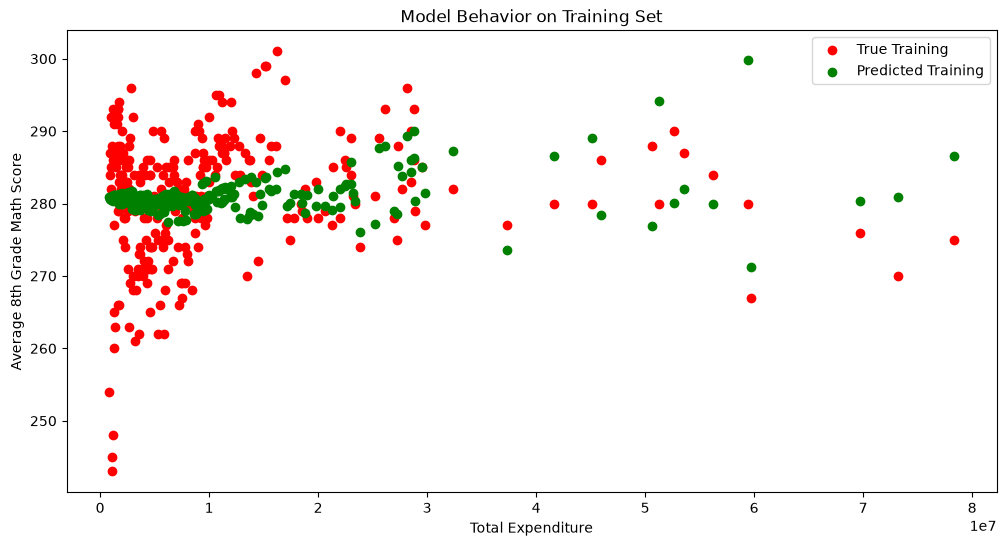

In [60]:
# @@@ 14


col_name = 'TOTAL_EXPENDITURE'

f = plt.figure(figsize=(12, 6))

plt.scatter(X_train[col_name], y_train, color='red')
plt.scatter(X_train[col_name], model.predict(X_train), color='green')

plt.legend(['True Training', 'Predicted Training'])
plt.xlabel('Total Expenditure')
plt.ylabel('Average 8th Grade Math Score')
plt.title('Model Behavior on Training Set')